**Repository review — 7 September 2026.** Outputs below are preserved from experiment commit 93676de; the updated source has not been re-executed on the original raw data. New safeguards invalidate the old code freeze. Restore the hash-matched inputs and run the experiment driver before Run All. Four historical benchmark quality-exposure exports disagree with summary tables; see REVIEW.md. Return and risk results are unaffected by that export discrepancy.

# Baseline — corrected, common GMV benchmark

## TL;DR

This notebook re-executes the original equal-weight and shrinkage-GMV comparison using consistent daily holdings drift, cost accounting and metric definitions. The 252-day/monthly/15%-cap specification is held fixed so the information-layer experiments share one control.

**Executed test result (2021-01-04–2026-02-20):** CAGR 9.16%; annual volatility 13.15%; daily CVaR95 1.86%; maximum drawdown 18.63%; annual two-sided turnover 3.23. Interpret these together with the incremental comparisons and uncertainty below.

In [1]:
from pathlib import Path
import os, sys, json, copy, warnings, tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "portfolio-mpl"))
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
# pandas 2.x / NumPy 2.4 emit this unrelated compatibility deprecation.
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from portfolio_research.workflow import *
from portfolio_research.features import prediction_diagnostics, forecast_risk, FEATURE_SETS
from portfolio_research.presentation import *
setup()
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "project": str(ROOT)})

## Context & Methods

The primary baseline is **constrained Ledoit–Wolf global minimum variance (GMV)** within the Markowitz framework. It is not a Gaussian-mixture model (GMM). The regime extension uses a **two-state Gaussian hidden Markov model (HMM)**, relabelled calm/stress by its volatility state means. Calm/stress need not coincide with bull/bear returns.

The original frozen implementation settings are retained across the main comparison: **252 prior trading sessions, monthly rebalancing, long only, fully invested, 15% maximum target weight, and 10 basis points per dollar traded**. Keeping these settings fixed isolates the incremental information layers. They are inherited controls, not claimed to be optimal after correcting the old backtest.

- **Train, 2000–2016:** rolling covariance/HMM estimation; CatBoost training snapshots begin in 2010 because historical SEC XBRL coverage is sparse before then.
- **Validation, 2017–2020:** select only new quality/ML settings using the baseline risk score: volatility 30%, CVaR95 25%, drawdown 20%, turnover 10%, HHI 10%, Sharpe 5% (reverse-ranked).
- **Test, 2021–2026-02-20:** a common evaluation window after freezing all new settings. Rolling estimators and annual CatBoost refits may learn from earlier, fully observed test history, as a live strategy would; future labels and test-dependent parameter choices are forbidden.

### Key Assumptions

1. Signals end strictly before the return they earn. Fundamental facts have an additional one-business-day publication embargo and must already be available at the actual previous trading close. Close-only data imply idealized execution at the previous close; auction delays, overnight implementation and market impact are not simulated.
2. Holdings **drift every day** between scheduled rebalances. Two-sided L1 turnover is measured against drifted holdings. Costs reduce capital multiplicatively: `net = (1 - cost) * (1 + gross) - 1`. Initial investment costs are included; terminal liquidation is not imposed.
3. Sortino uses the baseline definition: annualized mean divided by annualized root-mean-square negative returns, with a zero required return. All return/risk tables use net daily simple returns and 252 sessions/year. VaR/CVaR are daily positive loss magnitudes, not annualized estimates. Maximum drawdown includes initial wealth of 1.
4. Security caps apply at rebalancing; holdings may drift above the cap between trades. Cash yield, taxes, borrowing and capacity constraints are outside this fully invested research protocol.
5. The supplied 50 stocks were selected using full-history coverage and alphabetical tie-breaking. Historical delistings and index membership are missing. **Survivorship and universe-selection bias remain.** The data represent a narrow US equity sample, not an emerging market.
6. The original baseline notebook already exposed test results. This test is held out for the **new** hyperparameter choices; it is not a pristine preregistered replication. Previously reported numbers are superseded by the common corrected engine.

## Data

### Load the original three splits and audit the balanced panel

In [2]:
c = prepare_context()
display(c["summary"])
display(pd.DataFrame({"check": ["Price cells", "Missing prices", "Nonpositive prices", "Absolute daily returns > 20%"],
                      "value": [c["prices"].size, int(c["prices"].isna().sum().sum()), int(c["prices"].le(0).sum().sum()), int(c["returns"].abs().gt(.2).sum().sum())]}))
print("Common allocation settings:", asdict(CONFIG))

,start,end,days,assets,rows
split,,,,,
train,2000-01-03,2016-12-30,4277,50,213850
validation,2017-01-03,2020-12-31,1007,50,50350
test,2021-01-04,2026-02-20,1289,50,64450


,check,value
0,Price cells,328650
1,Missing prices,0
2,Nonpositive prices,0
3,Absolute daily returns > 20%,271


### Investigate large observed price moves

Large returns are listed for source review; they are not removed or winsorized using test outcomes.

In [3]:
extremes = c["returns"].stack().rename("simple_return").reset_index()
extremes = extremes.loc[extremes.simple_return.abs() > .2].sort_values("simple_return")
display(extremes.head(10))
print("All flagged observations:", len(extremes))
extremes.to_csv(ROOT / "artifacts/tables/price_extremes.csv", index=False)

,Date,Ticker,simple_return
109311,2008-09-15,AIG,-0.607889
253772,2020-03-09,APA,-0.538979
9351,2000-09-29,AAPL,-0.512500
21609,2001-09-26,AES,-0.494832
109411,2008-09-17,AIG,-0.453331
64688,2005-02-28,BIIB,-0.425535
9291,2000-09-27,BKNG,-0.423301
21291,2001-09-17,BKNG,-0.398035
115049,2009-02-27,C,-0.390419
10836,2000-11-09,BBY,-0.387549


### Estimation and constrained allocation

At each formation date, Ledoit–Wolf shrinkage estimates a covariance matrix from strictly prior simple returns. SLSQP solves `min w.T @ covariance @ w` with nonnegative weights, a unit budget and the common security cap. No expected-return forecast or CVaR objective enters the optimization.

In [4]:
from portfolio_research.regimes import solve_gmv
formation = c["splits"]["validation"][0]
snapshot = c["market"][formation]
example_weights, solver = solve_gmv(snapshot["baseline"], snapshot["assets"], CONFIG.max_weight)
display(example_weights.sort_values(ascending=False).head(15).rename("target_weight").to_frame().style.format("{:.2%}"))
print(solver)

,target_weight
AEP,11.80%
ALL,11.44%
ACGL,11.37%
AEE,10.70%
AFL,9.41%
AZO,8.74%
AXP,7.43%
BIO,6.31%
AVB,5.93%
BMY,4.68%


## Results

### Validation establishes the corrected benchmark

The original implementation grid selected these controls before the present work. The main comparison retains them rather than adding a second search over the same validation history.

In [5]:
validation_results = {name: strategy(c, "validation", name) for name in ["equal_weight", "baseline"]}
validation_table = metric_table(validation_results)
display(styled(validation_table[METRIC_COLUMNS]))
for name, result in validation_results.items(): verify_saved_result(result, name, "validation")

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
equal_weight,18.76%,21.94%,0.895,1.236,38.03%,3.49%,6.50%,0.846,50.000
baseline,15.42%,18.31%,0.876,1.213,33.51%,2.82%,5.77%,3.302,12.989


### Common test comparison

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
equal_weight,12.11%,16.85%,0.763,1.102,20.72%,2.41%,3.78%,0.833,50.000
baseline,9.16%,13.15%,0.733,1.043,18.63%,1.86%,2.88%,3.235,12.408


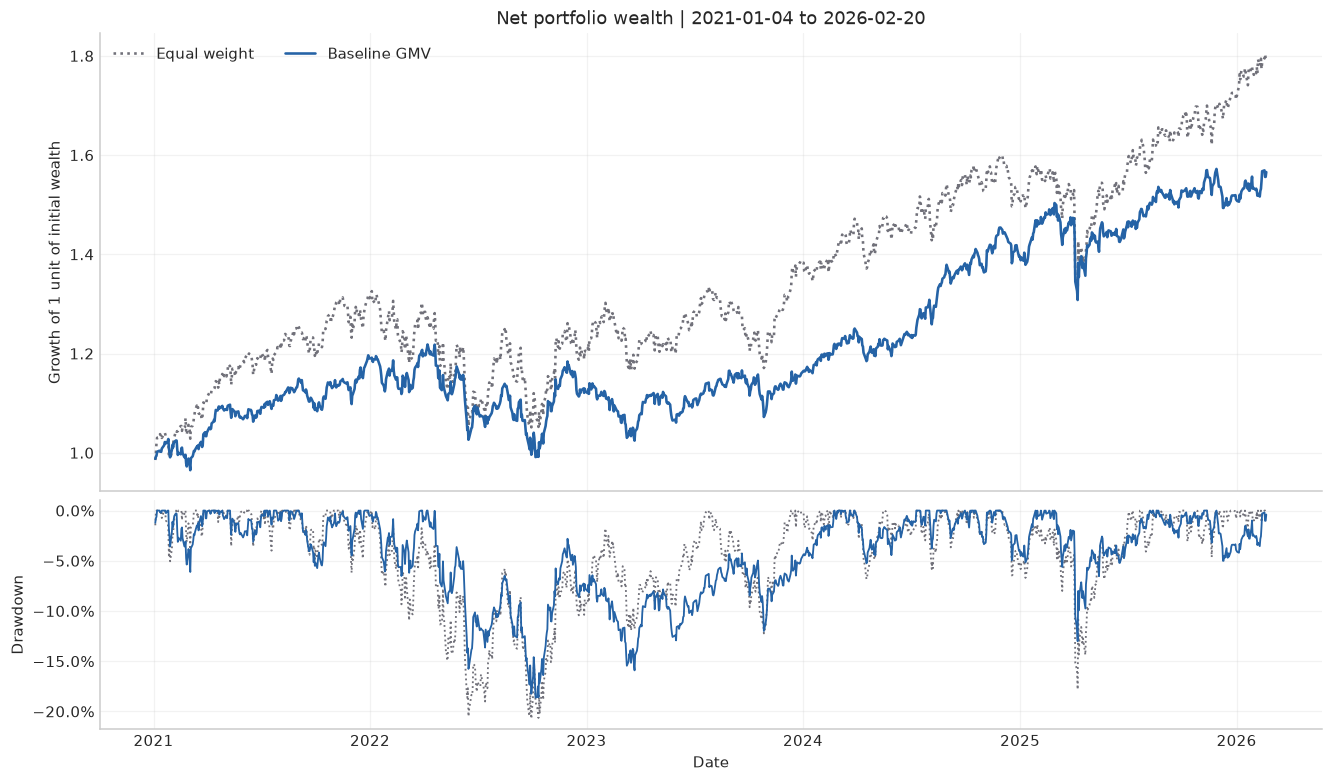

In [6]:
test_results = {name: strategy(c, "test", name) for name in ["equal_weight", "baseline"]}
test_table = metric_table(test_results)
display(styled(test_table[METRIC_COLUMNS]))
for name, result in test_results.items(): verify_saved_result(result, name, "test")
performance_plot(test_results, "baseline_test_performance")

### Reading the metrics

Lower volatility, CVaR and drawdown indicate less realized risk. Higher CAGR/Sharpe/Sortino indicate greater realized reward or reward per unit of risk. Turnover is the two-sided traded fraction per year, HHI is target-weight concentration, and effective breadth is `1 / HHI`. The sum of daily cost fractions is an implementation diagnostic, not the exact compounded drag on terminal wealth. Tables retain the baseline metric names and add implementation audits.

,Cumulative Return,Average Daily Return,Arithmetic Annual Return,Downside Deviation,Drawdown Duration,VaR 95%,VaR 99%,Average Turnover,Total Transaction Costs,Rebalances,Average HHI,Average Active Positions,Average Maximum Weight,Mean Target L1 Change,Solver Failures,HMM Fallbacks,Calmar
equal_weight,79.44%,0.05%,12.85%,11.66%,387.000,1.65%,2.90%,0.069,0.43%,62.000,2.00%,50.000,2.00%,0.000,0.000,0.000,0.585
baseline,56.58%,0.04%,9.63%,9.24%,469.000,1.29%,2.08%,0.267,1.65%,62.000,8.49%,20.065,13.70%,0.249,0.000,0.000,0.492


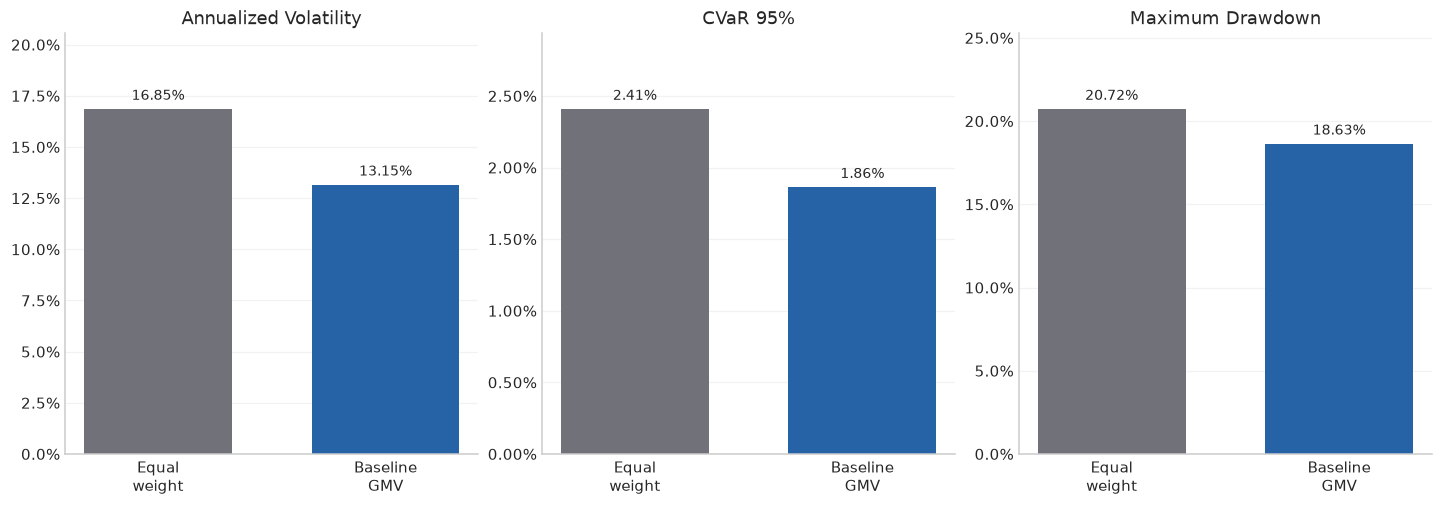

In [7]:
display(styled(test_table.drop(columns=METRIC_COLUMNS + ["Average Portfolio Quality"])))
risk_plot(test_table, "baseline_test_risk")

### Concentration and weight stability

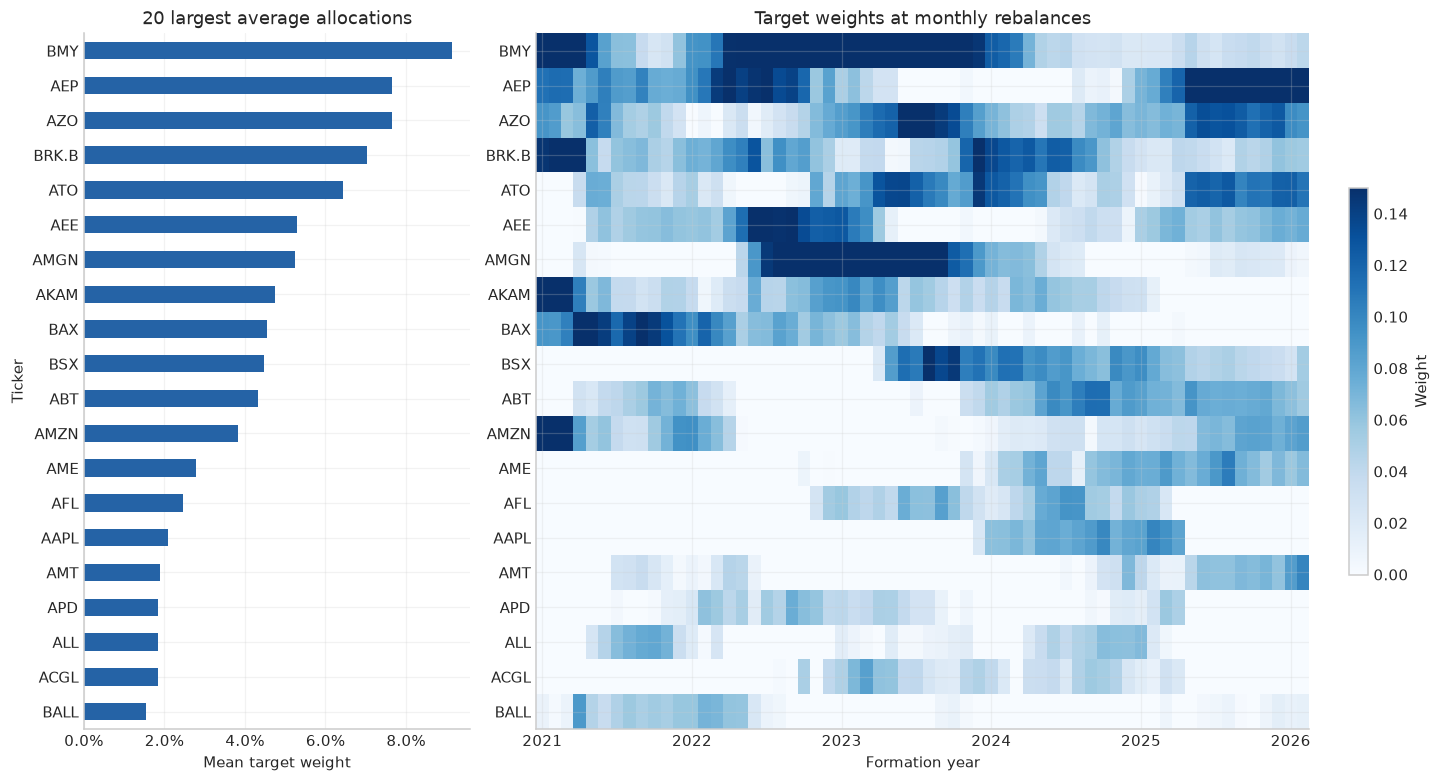

In [8]:
allocation_plot(test_results["baseline"], "baseline_test_weights")

### Paired uncertainty and trading-cost sensitivity

A paired moving-block bootstrap preserves daily alignment between strategies. Twenty-day blocks and 2,000 replications provide descriptive 95% intervals. They do not correct for model search or establish performance in another market.

In [9]:
uncertainty = paired_bootstrap(test_results["equal_weight"].returns.net_return, test_results["baseline"].returns.net_return)
display(uncertainty)
costs = cost_sensitivity(test_results)
display(styled(costs.set_index(["strategy", "cost_bps"])[["CAGR", "Sharpe", "CVaR 95%", "Total Transaction Costs"]]))

,difference,lower_95,upper_95
Annualized Volatility,-0.037007,-0.045191,-0.028862
CVaR 95%,-0.005456,-0.007251,-0.003975
Maximum Drawdown,-0.020897,-0.136357,0.066837
Sharpe,-0.030103,-0.542876,0.468442


## Takeaways

In [10]:
b = test_table.loc["baseline"]; e = test_table.loc["equal_weight"]
display(Markdown(f"""The corrected GMV baseline has **{b['Annualized Volatility']:.2%} annual volatility**, **{b['CVaR 95%']:.2%} daily CVaR95** and **{b['CAGR']:.2%} CAGR**. Equal weighting has {e['Annualized Volatility']:.2%} volatility and {e['CAGR']:.2%} CAGR. This establishes the risk–return trade-off that later layers must improve. The old manuscript values should not be mixed with these corrected results."""))
assert all(r.returns.index.equals(c["splits"]["test"]) for r in test_results.values())
print("All cells completed; accounting, timing and portfolio constraints verified.")

The corrected GMV baseline has **13.15% annual volatility**, **1.86% daily CVaR95** and **9.16% CAGR**. Equal weighting has 16.85% volatility and 12.11% CAGR. This establishes the risk–return trade-off that later layers must improve. The old manuscript values should not be mixed with these corrected results.

## Sources and methodological references

- Original local source notebooks: `price_EDA.ipynb`, `company_analisys.ipynb`; draft manuscript: `Portfolio optimization.docx`.
- [Kaggle price snapshot, version 1](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data): original selection and saved splits are preserved. The provider's `Adj Close` is used as supplied; dividend/corporate-action adjustment quality is not independently certified.
- [SEC EDGAR XBRL API documentation](https://www.sec.gov/search-filings/edgar-application-programming-interfaces), [SEC identity reference](https://www.sec.gov/files/company_tickers_exchange.json). Identity reference data are used only to link issuers, not as historical predictive features.
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/common), [regression objectives](https://catboost.ai/docs/en/concepts/loss-functions-regression).
- Markowitz (1952), Ledoit & Wolf (2004), Hamilton (1989), Asness et al. (2019), Prokhorenkova et al. (2018): conceptual sources cited in the manuscript. The bespoke feature score and optimization penalties here are experimental implementations, not replicas of those papers.